#  CHALLENGE DATA 

**Cours : Machine Learning — Projet Data | IFIE2 Données**  
**Auteur : Fresnel KENGNE - Carlos SIBEFEU**



## Maladie de Parkinson : Prédire et Corriger les Biais dans l'Évaluation du Score Moteur par Institut du Cerveau

## 0. Imports et chargement des données

In [44]:
#! pip install xgboost

#! pip install catboost

import numpy as np
import pandas as pd

# pour réaliser des visualisations
import matplotlib.pyplot as plt
import seaborn as sns


# geographiques
#from shapely.geometry import Point
#import geopandas as gpd
#from geopandas import GeoDataFrame
#import geoplot

# pour pré-traiter les données
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import Ridge
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import GroupKFold


from sklearn.linear_model import LinearRegression
from sklearn.metrics import root_mean_squared_error
import xgboost as xgb


In [45]:
# Chargement du jeu de données

X_train = pd.read_csv("données/X_train_6ZIKlTY.csv")
y_train = pd.read_csv("données/y_train_lXj6X5y.csv")
X_test = pd.read_csv("données/X_test_oiZ2ukx.csv")

In [46]:
X_train.head()

,Index,patient_id,cohort,sexM,gene,age_at_diagnosis,age,ledd,time_since_intake_on,time_since_intake_off,on,off
0,0,IPLP5212,A,0,LRRK2+,48.5,52.1,607.0,1.9,NaN,7.0,NaN
1,1,IPLP5212,A,0,LRRK2+,48.5,53.0,666.0,1.9,17.6,12.0,44.0
2,2,IPLP5212,A,0,LRRK2+,48.5,53.9,717.0,1.2,NaN,6.0,NaN
3,3,IPLP5212,A,0,LRRK2+,48.5,54.8,770.0,1.5,NaN,11.0,NaN
4,4,IPLP5212,A,0,LRRK2+,48.5,56.9,885.0,0.3,NaN,24.0,NaN


In [47]:
y_train.head()

,Index,target
0,0,34.7
1,1,38.1
2,2,41.6
3,3,44.9
4,4,52.0


In [48]:
X_test.head()

,Index,patient_id,cohort,sexM,gene,age_at_diagnosis,age,ledd,time_since_intake_on,time_since_intake_off,on,off,time_since_diagnosis
0,0,KQYS2327,A,1,NaN,43.8,48.5,791.0,1.7,NaN,25.0,NaN,4.7
1,1,KQYS2327,A,1,NaN,43.8,49.1,826.0,2.8,NaN,25.0,NaN,5.3
2,2,KQYS2327,A,1,NaN,43.8,49.5,848.0,0.7,13.8,33.0,41.0,5.7
3,3,KQYS2327,A,1,NaN,43.8,50.0,874.0,5.2,NaN,34.0,NaN,6.2
4,4,KQYS2327,A,1,NaN,43.8,50.8,924.0,3.4,13.7,30.0,47.0,7.0


### Explication des features

| Index                     | Description |
|---------------------------|-------------|
| Index                     | Index |
| patient_id                | ID Patient |
| cohort                    | ID Cohorte (groupe) |
| sexM                      | Genre |
| gene                      | Marqueurs génétiques |
| age_at_diagnosis          | Âge au moment du diagnostique |
| age                       | Âge |
| ledd                      | Posologie médicament lévodopa en dose quotidienne équivalente (LEDD) |
| time_since_intake_on      | Délai depuis dernière prise de médicament pour Score ON |
| time_since_intake_off     | Délai depuis dernière prise de médicament pour Score OFF |
| on                        | Score ON |
| off                       | Score OFF |
| time_since_diagnosis      | Temps écoulé depuis le diagnostic |

## 1. Exploration du Jeu de Données


In [49]:
# On vérifie la taille des dataset
X_train.shape, y_train.shape, X_test.shape

((55603, 12), (55603, 2), (23672, 13))

In [50]:
# Informations sur le dataset
X_train.info()


<class 'pandas.DataFrame'>
RangeIndex: 55603 entries, 0 to 55602
Data columns (total 12 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Index                  55603 non-null  int64  
 1   patient_id             55603 non-null  str    
 2   cohort                 55603 non-null  str    
 3   sexM                   55603 non-null  int64  
 4   gene                   37645 non-null  str    
 5   age_at_diagnosis       52773 non-null  float64
 6   age                    55603 non-null  float64
 7   ledd                   35010 non-null  float64
 8   time_since_intake_on   29663 non-null  float64
 9   time_since_intake_off  11775 non-null  float64
 10  on                     38944 non-null  float64
 11  off                    32196 non-null  float64
dtypes: float64(7), int64(2), str(3)
memory usage: 5.1 MB


In [51]:
# Pourcentage de valeurs nulles par colonnes
(X_train.isnull().mean() * 100).sort_values(ascending=False)

time_since_intake_off    78.823085
time_since_intake_on     46.652159
off                      42.096649
ledd                     37.035771
gene                     32.296819
on                       29.960614
age_at_diagnosis          5.089653
Index                     0.000000
sexM                      0.000000
cohort                    0.000000
patient_id                0.000000
age                       0.000000
dtype: float64

In [52]:
X_train["gene"].unique()

<StringArray>
['LRRK2+', 'No Mutation', nan, 'GBA+', 'OTHER+']
Length: 5, dtype: str

In [53]:
X_test["gene"].unique()

<StringArray>
[nan, 'No Mutation', 'LRRK2+', 'GBA+', 'OTHER+']
Length: 5, dtype: str

In [54]:
(X_test.isnull().mean() * 100).sort_values(ascending=False)

time_since_intake_off    78.747043
time_since_intake_on     47.296384
off                      41.272389
ledd                     37.449307
gene                     32.794018
on                       30.686043
cohort                    0.000000
patient_id                0.000000
Index                     0.000000
sexM                      0.000000
age                       0.000000
age_at_diagnosis          0.000000
time_since_diagnosis      0.000000
dtype: float64

In [55]:
y_train.isnull().sum()

Index     0
target    0
dtype: int64

Notre dataset de variables cibles ne contient pas de valeurs nulles.

In [56]:
# Description des datasets
X_train.describe()

,Index,sexM,age_at_diagnosis,age,ledd,time_since_intake_on,time_since_intake_off,on,off
count,55603.000000,55603.000000,52773.000000,55603.000000,35010.000000,29663.000000,11775.000000,38944.000000,32196.000000
mean,27801.000000,0.596353,56.734648,62.516422,638.102228,1.953717,14.199448,21.985980,26.295316
std,16051.347846,0.490633,10.823093,11.484480,219.443182,1.168793,2.844782,10.371291,16.534567
min,0.000000,0.000000,16.500000,16.500000,50.000000,0.000000,6.900000,0.000000,0.000000
25%,13900.500000,0.000000,49.500000,54.900000,481.000000,1.100000,12.200000,14.000000,13.000000
50%,27801.000000,1.000000,56.900000,62.500000,611.000000,1.600000,13.800000,21.000000,24.000000
75%,41701.500000,1.000000,64.400000,70.500000,765.000000,2.600000,15.700000,28.000000,38.000000
max,55602.000000,1.000000,89.900000,103.300000,1796.000000,6.300000,25.100000,95.000000,106.000000


In [57]:
X_test.describe()

,Index,sexM,age_at_diagnosis,age,ledd,time_since_intake_on,time_since_intake_off,on,off,time_since_diagnosis
count,23672.000000,23672.000000,23672.000000,23672.000000,14807.000000,12476.000000,5031.000000,16408.000000,13902.000000,23672.000000
mean,11835.500000,0.615960,56.393545,62.099159,637.611332,1.958216,14.135202,22.233057,26.316070,5.705615
std,6833.662122,0.486378,10.426912,11.333973,214.153023,1.172925,2.853948,10.736239,16.851214,4.455499
min,0.000000,0.000000,18.800000,19.100000,50.000000,0.000000,7.300000,0.000000,0.000000,-28.695144
25%,5917.750000,0.000000,49.600000,54.400000,486.000000,1.100000,12.200000,14.000000,13.000000,2.600000
50%,11835.500000,1.000000,56.295144,61.900000,616.000000,1.600000,13.800000,21.000000,24.000000,5.200000
75%,17753.250000,1.000000,63.600000,70.100000,764.500000,2.600000,15.600000,29.000000,37.750000,8.404856
max,23671.000000,1.000000,83.200000,100.600000,1562.000000,6.400000,25.000000,93.000000,108.000000,33.204856


In [58]:
X_train["time_since_diagnosis"] = X_train["age"] - X_train["age_at_diagnosis"]

for df in [X_train, X_test]:
    df["time_since_diagnosis"] = df["age"] - df["age_at_diagnosis"]
    df["age_ratio"] = df["age"] / (df["age_at_diagnosis"] + 1)
    df["age_squared"] = df["age"] ** 2
    df["log_age"] = np.log1p(df["age"])
    df["interaction"] = df["age"] * df["gene"].astype('category').cat.codes
        # La variable d'or pour Parkinson : l'efficacité du traitement
    df['delta_on_off'] = df['off'] - df['on']
    df['ratio_on_off'] = df['off'] / (df['on'] + 1)
    
    # Indicateurs de progression
    df['years_since_diag'] = df['age'] - df['age_at_diagnosis']
    
    # Dose cumulée potentielle (simplifiée)
    df['dose_efficiency'] = df['ledd'] / (df['time_since_intake_on'] + 0.1)

    # Statistiques par patient (Signal fort)
    df['patient_avg_ledd'] = df.groupby('patient_id')['ledd'].transform('mean')
    df['patient_max_off'] = df.groupby('patient_id')['off'].transform('max')


# On peut maintenant supprimer patient_id mais on garde l'info pour le GroupKFold
patient_ids_train = X_train['patient_id']
 


In [59]:
y_train.describe()

,Index,target
count,55603.000000,55603.000000
mean,27801.000000,37.331606
std,16051.347846,16.504326
min,0.000000,0.000000
25%,13900.500000,25.400000
50%,27801.000000,37.100000
75%,41701.500000,49.200000
max,55602.000000,109.500000


Au vu de tout ce traitement, on pourrait : 
- Effacer les données manquantes
- Les remplacer par la médiane
- Effacer les colonnes qui semblent nous servir à rien: index, patientid, cohort, age(car on a deja l'ae de diagnostic et la durée entre cette date et la prise de l'enregistrement)
- Effacer le sexe puis travailler avec


In [60]:
#Concatenation de X_train et y_train
df = pd.concat([X_train, y_train], axis=1)
df.shape

(55603, 25)

In [61]:
#Suppression des colonnes inutiles
X_test = X_test.drop(columns=["Index"])
X_train = X_train.drop(columns=["Index"])
y_train= y_train.drop(columns=["Index"])
df = df.drop(columns=["Index"])
df.shape

(55603, 23)

In [62]:
df.head()

,patient_id,cohort,sexM,gene,age_at_diagnosis,age,ledd,time_since_intake_on,time_since_intake_off,on,...,age_squared,log_age,interaction,delta_on_off,ratio_on_off,years_since_diag,dose_efficiency,patient_avg_ledd,patient_max_off,target
0,IPLP5212,A,0,LRRK2+,48.5,52.1,607.0,1.9,NaN,7.0,...,2714.41,3.972177,52.1,NaN,NaN,3.6,303.500000,872.454545,54.0,34.7
1,IPLP5212,A,0,LRRK2+,48.5,53.0,666.0,1.9,17.6,12.0,...,2809.00,3.988984,53.0,32.0,3.384615,4.5,333.000000,872.454545,54.0,38.1
2,IPLP5212,A,0,LRRK2+,48.5,53.9,717.0,1.2,NaN,6.0,...,2905.21,4.005513,53.9,NaN,NaN,5.4,551.538462,872.454545,54.0,41.6
3,IPLP5212,A,0,LRRK2+,48.5,54.8,770.0,1.5,NaN,11.0,...,3003.04,4.021774,54.8,NaN,NaN,6.3,481.250000,872.454545,54.0,44.9
4,IPLP5212,A,0,LRRK2+,48.5,56.9,885.0,0.3,NaN,24.0,...,3237.61,4.058717,56.9,NaN,NaN,8.4,2212.500000,872.454545,54.0,52.0


In [63]:
#tableau de correlation des variables numeriques
dfNum = df.drop(columns=["cohort","gene","patient_id"])
dfNum.corr()


,sexM,age_at_diagnosis,age,ledd,time_since_intake_on,time_since_intake_off,on,off,time_since_diagnosis,age_ratio,age_squared,log_age,interaction,delta_on_off,ratio_on_off,years_since_diag,dose_efficiency,patient_avg_ledd,patient_max_off,target
sexM,1.000000,0.014815,0.010389,-0.018867,0.005180,-0.002611,0.020936,-0.002773,-0.014566,-0.020811,0.009593,0.011355,0.007177,-0.020358,-0.052285,-0.014566,-0.007882,-0.017304,-0.005713,-0.001603
age_at_diagnosis,0.014815,1.000000,0.941416,-0.160554,-0.004835,0.004601,0.038912,0.122826,0.000512,-0.251643,0.929415,0.935664,0.073849,0.106676,0.043040,0.000512,-0.045331,-0.191126,0.108659,0.127892
age,0.010389,0.941416,1.000000,0.076056,-0.003806,0.009428,0.124102,0.253538,0.337729,0.079517,0.991710,0.989435,0.078689,0.170872,0.048365,0.337729,0.027750,-0.053094,0.188765,0.304531
ledd,-0.018867,-0.160554,0.076056,1.000000,-0.001576,0.024608,0.211127,0.227920,0.714862,0.688650,0.082533,0.068756,0.012598,0.151303,0.006104,0.714862,0.291735,0.873986,0.107721,0.299595
time_since_intake_on,0.005180,-0.004835,-0.003806,-0.001576,1.000000,0.006807,-0.220349,-0.008982,0.000713,0.003476,-0.004365,-0.003041,0.002847,0.289371,0.378415,0.000713,-0.478245,-0.002683,-0.007166,0.002087
time_since_intake_off,-0.002611,0.004601,0.009428,0.024608,0.006807,1.000000,0.002520,0.038192,0.017587,0.012441,0.007755,0.010746,-0.003523,0.068717,0.065427,0.017587,-0.000158,0.025030,0.008852,0.011191
on,0.020936,0.038912,0.124102,0.211127,-0.220349,0.002520,1.000000,0.867842,0.263368,0.223170,0.128062,0.117496,0.008131,0.321729,-0.297037,0.263368,0.312277,0.109294,0.537230,0.687351
off,-0.002773,0.122826,0.253538,0.227920,-0.008982,0.038192,0.867842,1.000000,0.425178,0.375764,0.257670,0.244623,-0.000883,0.749635,0.146887,0.425178,0.083733,-0.020801,0.773711,0.885098
time_since_diagnosis,-0.014566,0.000512,0.337729,0.714862,0.000713,0.017587,0.263368,0.425178,1.000000,0.938108,0.346523,0.322254,0.029445,0.211542,0.016889,1.000000,0.210760,0.374444,0.252873,0.542539
age_ratio,-0.020811,-0.251643,0.079517,0.688650,0.003476,0.012441,0.223170,0.375764,0.938108,1.000000,0.088586,0.068113,0.012584,0.148863,-0.007895,0.938108,0.202860,0.397042,0.207756,0.477363


In [64]:
X_test.info()

<class 'pandas.DataFrame'>
RangeIndex: 23672 entries, 0 to 23671
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             23672 non-null  str    
 1   cohort                 23672 non-null  str    
 2   sexM                   23672 non-null  int64  
 3   gene                   15909 non-null  str    
 4   age_at_diagnosis       23672 non-null  float64
 5   age                    23672 non-null  float64
 6   ledd                   14807 non-null  float64
 7   time_since_intake_on   12476 non-null  float64
 8   time_since_intake_off  5031 non-null   float64
 9   on                     16408 non-null  float64
 10  off                    13902 non-null  float64
 11  time_since_diagnosis   23672 non-null  float64
 12  age_ratio              23672 non-null  float64
 13  age_squared            23672 non-null  float64
 14  log_age                23672 non-null  float64
 15  interaction  

In [65]:
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 55603 entries, 0 to 55602
Data columns (total 22 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   patient_id             55603 non-null  str    
 1   cohort                 55603 non-null  str    
 2   sexM                   55603 non-null  int64  
 3   gene                   37645 non-null  str    
 4   age_at_diagnosis       52773 non-null  float64
 5   age                    55603 non-null  float64
 6   ledd                   35010 non-null  float64
 7   time_since_intake_on   29663 non-null  float64
 8   time_since_intake_off  11775 non-null  float64
 9   on                     38944 non-null  float64
 10  off                    32196 non-null  float64
 11  time_since_diagnosis   52773 non-null  float64
 12  age_ratio              52773 non-null  float64
 13  age_squared            55603 non-null  float64
 14  log_age                55603 non-null  float64
 15  interaction  

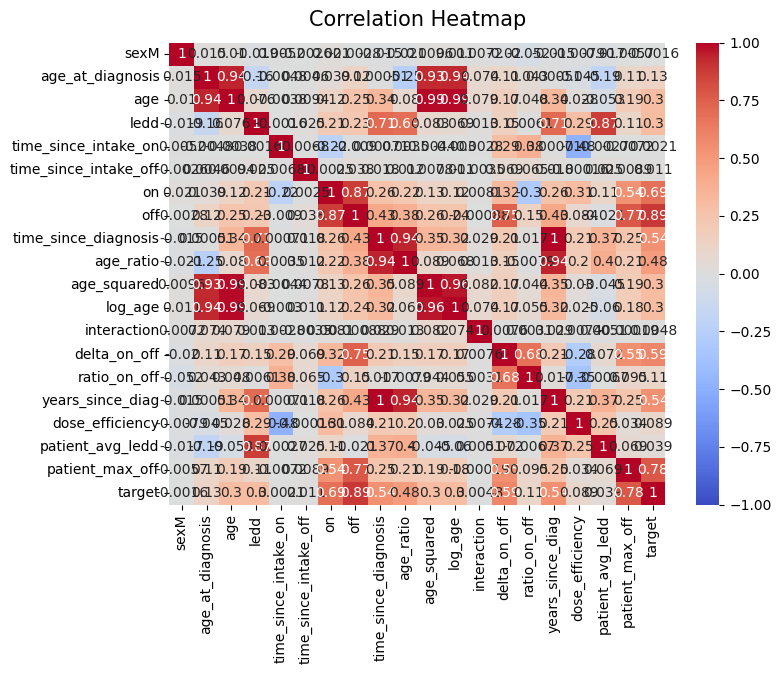

In [66]:
#Graphique visuelle du tableau de correlation
plt.figure(figsize=(8, 6))
heatmap = sns.heatmap(dfNum.corr(),cmap= "coolwarm" ,vmin=-1, vmax=1, annot=True)
heatmap.set_title('Correlation Heatmap', fontdict={'fontsize':15}, pad=12);

# Split en cours de telechargement
gkf = GroupKFold(n_splits=5)
y = df["target"]
X = df.drop(columns=["target"])

# On sépare le jeu de données en jeu d'entraînement et en jeu de test
#X_tr, X_ts, y_tr, y_ts = train_test_split(X, y, test_size=0.2, random_state=42)



for fold, (train_idx, val_idx) in enumerate(gkf.split(X, y, groups=X["patient_id"])):

    print(f"\n🔹 Fold {fold+1}")

    # Split
    X_tr, X_ts = X.iloc[train_idx].copy(), X.iloc[val_idx].copy()
    y_tr, y_ts = y.iloc[train_idx], y.iloc[val_idx]

# On vérifie la taille de chacun des jeux = leur somme doit être égale au jeu de départ

X_tr.shape, X_ts.shape,y_tr.shape,y_ts.shape

## 2. Feature engineering 



In [67]:
##Gestion des valeurs manquantes (Mediane)

#valeurs numeriques
num_cols = X_train.select_dtypes(include=np.number).columns

for col in num_cols:
    X_train[col] = X_train[col].fillna(X_train.groupby("patient_id")[col].transform("median"))
   # X_ts[col] = X_ts[col].fillna(X_ts.groupby("patient_id")[col].transform("median"))
    X_test[col] = X_test[col].fillna(X_test.groupby("patient_id")[col].transform("median"))
    
          # 2. Fallback global si encore NaN
    global_median = X_train[col].median()

    X_train[col] = X_train[col].fillna(global_median)
    X_test[col] = X_test[col].fillna(global_median)




cat_cols = X_train.select_dtypes(exclude=np.number).columns

for col in cat_cols:
    X_train[col] = X_train[col].fillna(
        X_train.groupby("patient_id")[col].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    )
    #X_ts[col] = X_ts[col].fillna(
      #  X_ts.groupby("patient_id")[col].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
   # )
    X_test[col] = X_test[col].fillna(
        X_test.groupby("patient_id")[col].transform(lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan)
    )

        # 🔹 2. Fallback global
    global_mode = X_train[col].mode()[0]
    X_train[col] = X_train[col].fillna(global_mode)
   # X_ts[col] = X_ts[col].fillna(global_mode)
    X_test[col] = X_test[col].fillna(global_mode)

    # 🔹 3. Conversion string (OBLIGATOIRE pour CatBoost)
    X_train[col] = X_train[col].astype(str)
    X_test[col] = X_test[col].astype(str)

''' cat_cols = ["gene", "cohort"]

for col in cat_cols:
    X_train[col] = X_train[col].fillna("missing").astype(str)
    X_test[col] = X_test[col].fillna("missing").astype(str) '''




X_train.isna().sum()

patient_id               0
cohort                   0
sexM                     0
gene                     0
age_at_diagnosis         0
age                      0
ledd                     0
time_since_intake_on     0
time_since_intake_off    0
on                       0
off                      0
time_since_diagnosis     0
age_ratio                0
age_squared              0
log_age                  0
interaction              0
delta_on_off             0
ratio_on_off             0
years_since_diag         0
dose_efficiency          0
patient_avg_ledd         0
patient_max_off          0
dtype: int64

In [68]:
X_train = X_train.drop(columns=["patient_id"])
#X_test = X_test.drop(columns=["patient_id"])
X_test = X_test.drop(columns=["patient_id"])


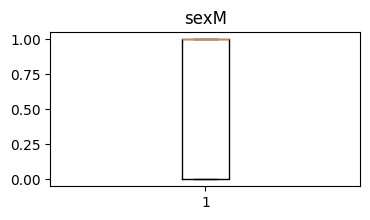

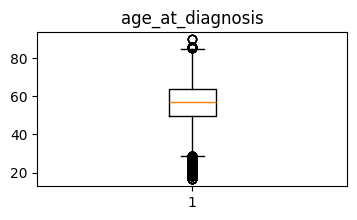

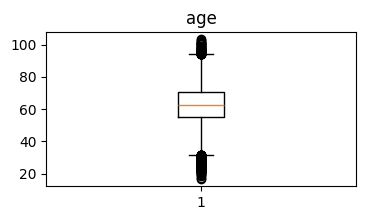

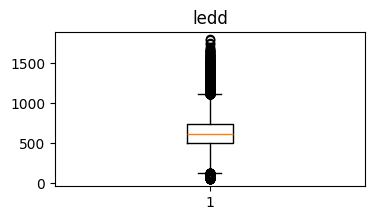

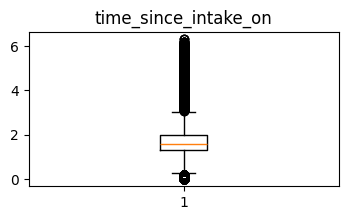

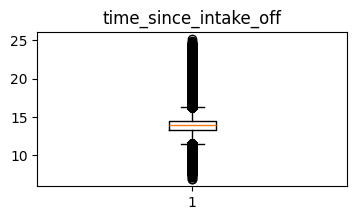

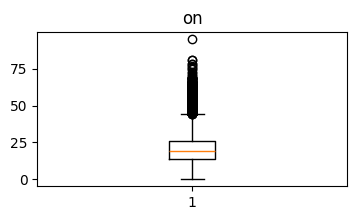

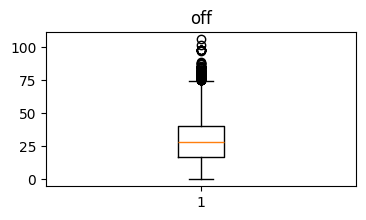

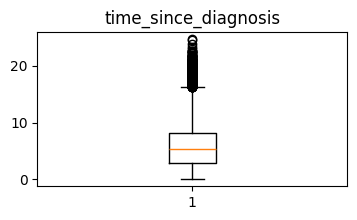

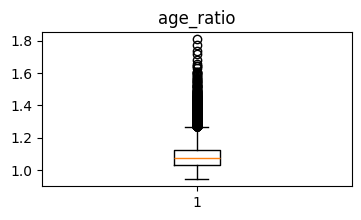

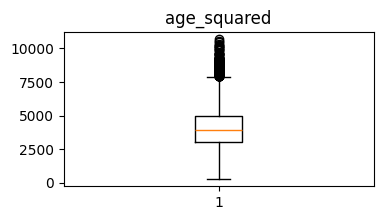

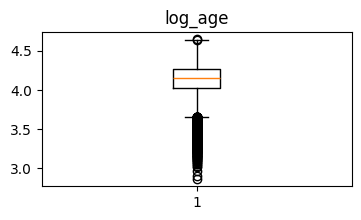

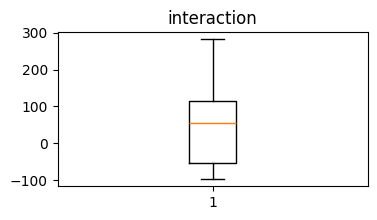

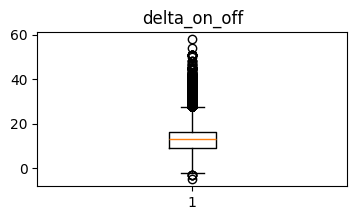

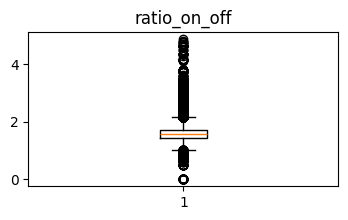

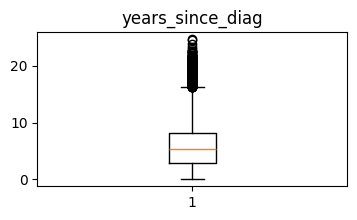

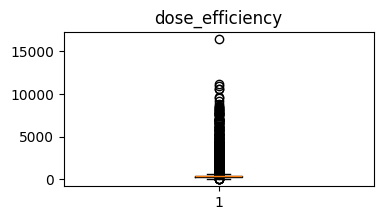

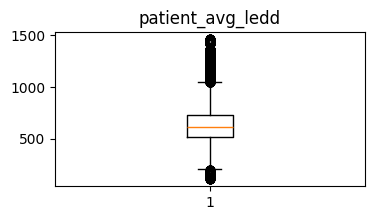

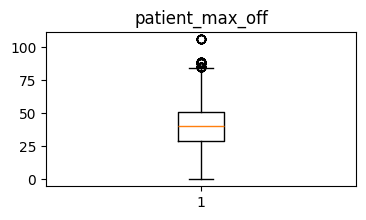

In [69]:
#Boxplot pour visualiser les valeurs aberrantes

num_cols = X_train.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(4, 2))
    plt.boxplot(X_train[col])
    plt.title(col)
    plt.show()

In [70]:
# Gestion des valeurs aberrantes (winsorization)
Q1 = X_train[num_cols].quantile(0.25)
Q3 = X_train[num_cols].quantile(0.75)
IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

# Capping sur train et test avec les mêmes bornes
X_train[num_cols] = X_train[num_cols].clip(lower=lower, upper=upper, axis=1)
X_test[num_cols] = X_test[num_cols].clip(lower=lower, upper=upper, axis=1)

X_train[num_cols].describe()

,sexM,age_at_diagnosis,age,ledd,time_since_intake_on,time_since_intake_off,on,off,time_since_diagnosis,age_ratio,age_squared,log_age,interaction,delta_on_off,ratio_on_off,years_since_diag,dose_efficiency,patient_avg_ledd,patient_max_off
count,55603.000000,55603.000000,55603.000000,55603.000000,55603.000000,55603.000000,55603.000000,55603.000000,55603.000000,55603.000000,55603.000000,55603.000000,55603.000000,55603.000000,55603.000000,55603.000000,55603.000000,55603.000000,55603.00000
mean,0.596353,56.772033,62.531894,632.392749,1.733373,13.928528,20.615551,28.991907,5.786600,1.085370,4036.151723,4.136299,38.212237,13.339163,1.602589,5.786600,369.706314,631.958568,40.57184
std,0.490633,10.454362,11.418450,190.864626,0.674926,1.294509,9.117565,15.672195,3.727977,0.068730,1421.381869,0.183396,84.255812,5.956256,0.255026,3.727977,154.070644,170.178892,15.12986
min,0.000000,28.750000,31.500000,132.500000,0.250000,11.500000,0.000000,0.000000,0.000000,0.942857,272.250000,3.654365,-97.300000,-2.250000,1.026786,0.000000,24.901889,199.225000,0.00000
25%,0.000000,49.900000,54.900000,500.000000,1.300000,13.300000,14.000000,17.000000,2.800000,1.032046,3014.010000,4.023564,-53.900000,9.000000,1.450000,2.800000,273.693957,517.750000,29.00000
50%,1.000000,56.900000,62.500000,614.000000,1.600000,13.900000,19.000000,28.000000,5.300000,1.074184,3906.250000,4.151040,54.900000,13.000000,1.588235,5.300000,349.838710,614.727273,40.00000
75%,1.000000,64.000000,70.500000,745.000000,2.000000,14.500000,26.000000,40.000000,8.200000,1.127193,4970.250000,4.269697,115.600000,16.500000,1.732143,8.200000,439.555336,730.100000,51.00000
max,1.000000,85.150000,93.900000,1112.500000,3.050000,16.300000,44.000000,74.500000,16.300000,1.269914,7904.610000,4.638897,282.000000,27.750000,2.155357,16.300000,688.347404,1048.625000,84.00000


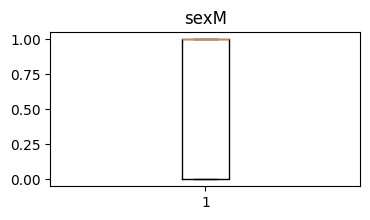

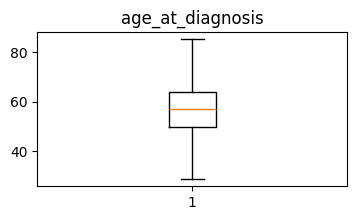

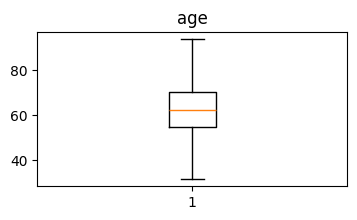

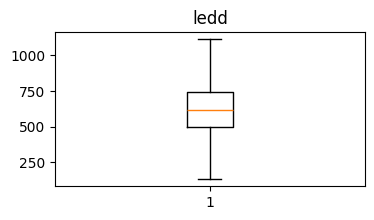

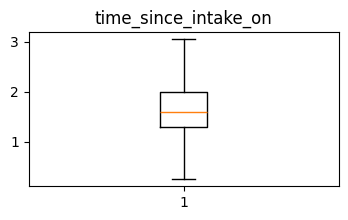

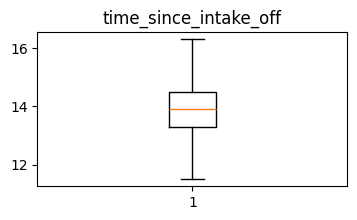

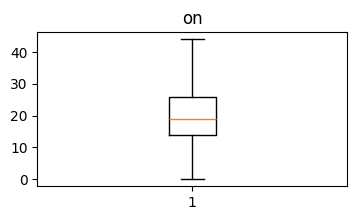

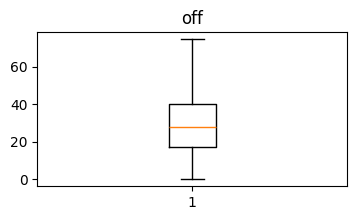

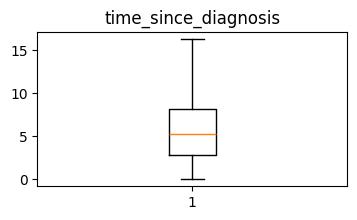

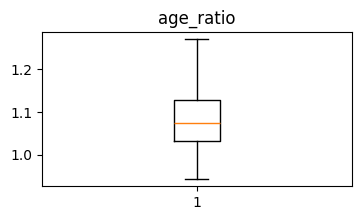

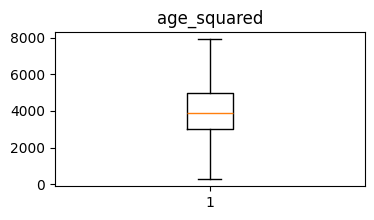

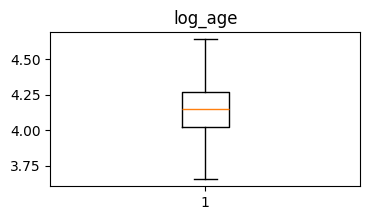

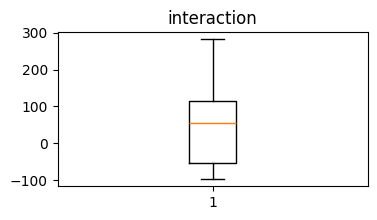

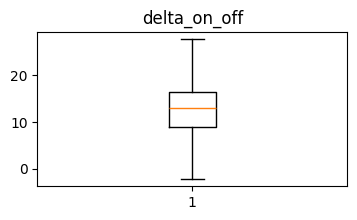

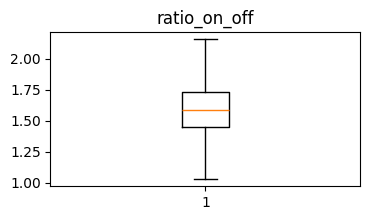

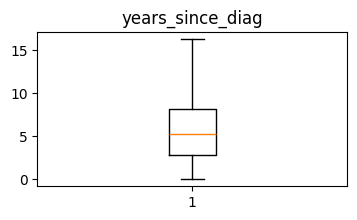

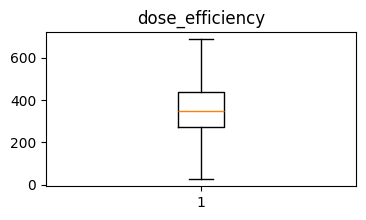

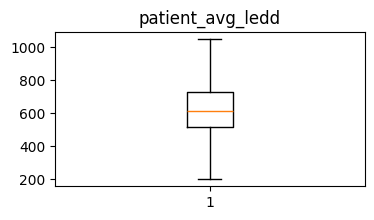

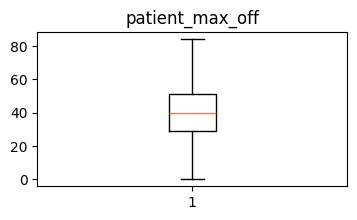

In [71]:
#verification
num_cols = X_train.select_dtypes(include=np.number).columns

for col in num_cols:
    plt.figure(figsize=(4, 2))
    plt.boxplot(X_train[col])
    plt.title(col)
    plt.show()

In [72]:
  ##Gestion des variables categorielles
X_train_cat = X_train.copy()
#X_test_cat = X_test.copy()
X_test_cat = X_test.copy()


# Colonnes qui nous intéressent
cat_cols_shit = ["cohort","gene"]

# Initialisation de l'encoder
shit = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
shit.fit(X_train[cat_cols_shit])

train_ohe = pd.DataFrame(
    shit.transform(X_train[cat_cols_shit]),
    index=X_train.index,
    columns=shit.get_feature_names_out(cat_cols_shit),
)


test_high = pd.DataFrame(
    shit.transform(X_test[cat_cols_shit]),
    index=X_test.index,
    columns=shit.get_feature_names_out(cat_cols_shit),
)

X_train = X_train.drop(columns=cat_cols_shit).join(train_ohe)
X_test = X_test.drop(columns=cat_cols_shit).join(test_high)

X_train.shape, X_test.shape

((55603, 25), (23672, 25))

In [73]:
X_train.head()

,sexM,age_at_diagnosis,age,ledd,time_since_intake_on,time_since_intake_off,on,off,time_since_diagnosis,age_ratio,...,years_since_diag,dose_efficiency,patient_avg_ledd,patient_max_off,cohort_A,cohort_B,gene_GBA+,gene_LRRK2+,gene_No Mutation,gene_OTHER+
0,0,48.5,52.1,607.0,1.9,14.7,7.0,43.0,3.6,1.052525,...,3.6,303.500000,872.454545,54.0,1.0,0.0,0.0,1.0,0.0,0.0
1,0,48.5,53.0,666.0,1.9,16.3,12.0,44.0,4.5,1.070707,...,4.5,333.000000,872.454545,54.0,1.0,0.0,0.0,1.0,0.0,0.0
2,0,48.5,53.9,717.0,1.2,14.7,6.0,43.0,5.4,1.088889,...,5.4,551.538462,872.454545,54.0,1.0,0.0,0.0,1.0,0.0,0.0
3,0,48.5,54.8,770.0,1.5,14.7,11.0,43.0,6.3,1.107071,...,6.3,481.250000,872.454545,54.0,1.0,0.0,0.0,1.0,0.0,0.0
4,0,48.5,56.9,885.0,0.3,14.7,24.0,43.0,8.4,1.149495,...,8.4,688.347404,872.454545,54.0,1.0,0.0,0.0,1.0,0.0,0.0


In [74]:
#bien propre , bien soigné
X_train.info()

<class 'pandas.DataFrame'>
RangeIndex: 55603 entries, 0 to 55602
Data columns (total 25 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   sexM                   55603 non-null  int64  
 1   age_at_diagnosis       55603 non-null  float64
 2   age                    55603 non-null  float64
 3   ledd                   55603 non-null  float64
 4   time_since_intake_on   55603 non-null  float64
 5   time_since_intake_off  55603 non-null  float64
 6   on                     55603 non-null  float64
 7   off                    55603 non-null  float64
 8   time_since_diagnosis   55603 non-null  float64
 9   age_ratio              55603 non-null  float64
 10  age_squared            55603 non-null  float64
 11  log_age                55603 non-null  float64
 12  interaction            55603 non-null  float64
 13  delta_on_off           55603 non-null  float64
 14  ratio_on_off           55603 non-null  float64
 15  years_since_d

In [75]:
#Standardisation bien soigné
scaler = StandardScaler()

X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
#X_test[num_cols] = scaler.transform(X_test[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

---

## 3. Linear Regression & XGBOOST




In [76]:
from sklearn.model_selection import GroupKFold


# On utilise GroupKFold pour respecter l'indépendance des patients
gkf = GroupKFold(n_splits=5)
groups = patient_ids_train

In [77]:
# Light


lgb_model = lgb.LGBMRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=5,
    random_state=42
)


# XGBoost
xgb_model = xgb.XGBRegressor(
    n_estimators=2000,
    learning_rate=0.03,
    max_depth=5,
    random_state=42
)





In [78]:
'''# Prédictions avec le meilleur modèle (ex : XGBoost)
y_test = xgb_model.predict(X_test)

# Créer un dataset avec les prédictions
df_predictions = pd.DataFrame({
    "id": X_test.index,
    "y_test": y_test
})

# Sauvegarder en CSV
df_predictions.to_csv("y_test_pred1.csv", index=False)

print("Fichier y_test_predictions.csv généré.")'''

'# Prédictions avec le meilleur modèle (ex : XGBoost)\ny_test = xgb_model.predict(X_test)\n\n# Créer un dataset avec les prédictions\ndf_predictions = pd.DataFrame({\n    "id": X_test.index,\n    "y_test": y_test\n})\n\n# Sauvegarder en CSV\ndf_predictions.to_csv("y_test_pred1.csv", index=False)\n\nprint("Fichier y_test_predictions.csv généré.")'

CATBOOST
--------
--------

In [79]:
from catboost import CatBoostRegressor

cat_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.03,
    depth=6,
    random_state=42,
    verbose=0
)

#cat_features = ["gene","cohort"]




In [80]:
'''# Prédictions avec le meilleur modèle (ex : CatBoost)
y_test_cat = cat_model.predict(X_test_cat)
# Créer un dataset avec les prédictions
df_predictions = pd.DataFrame({
    "id": X_test.index,
    "y_test": y_test_cat
})  
#Sauvegarder en CSV
df_predictions.to_csv("y_test_pred2.csv", index=False)
print("Fichier y_test_predictions.csv généré.")'''

'# Prédictions avec le meilleur modèle (ex : CatBoost)\ny_test_cat = cat_model.predict(X_test_cat)\n# Créer un dataset avec les prédictions\ndf_predictions = pd.DataFrame({\n    "id": X_test.index,\n    "y_test": y_test_cat\n})  \n#Sauvegarder en CSV\ndf_predictions.to_csv("y_test_pred2.csv", index=False)\nprint("Fichier y_test_predictions.csv généré.")'

In [81]:
oof_xgb = np.zeros(len(X_train))
oof_cat = np.zeros(len(X_train))

oof_lgb = np.zeros(len(X_train))
pred_lgb = np.zeros(len(X_test))

pred_xgb = np.zeros(len(X_test))
pred_cat = np.zeros(len(X_test))

In [82]:
for fold, (train_idx, val_idx) in enumerate(gkf.split(X_train, y_train['target'], groups=groups)):

    # XGB/ light data
    X_tr_xgb = X_train.iloc[train_idx]
    X_val_xgb = X_train.iloc[val_idx]

    # CAT data
    X_tr_cat = X_train_cat.iloc[train_idx]
    X_val_cat = X_train_cat.iloc[val_idx]

    y_tr, y_val = y_train['target'].iloc[train_idx], y_train['target'].iloc[val_idx]

    # XGBoost
    xgb_model.fit(
        X_tr_xgb, y_tr,
        eval_set=[(X_val_xgb, y_val)],
        verbose=False
    )

    oof_xgb[val_idx] = xgb_model.predict(X_val_xgb)
    pred_xgb += xgb_model.predict(X_test) / 5

        # LightGBM 
    lgb_model.fit(
        X_tr_xgb, y_tr,
        eval_set=[(X_val_xgb, y_val)],
        callbacks=[lgb.early_stopping(100, verbose=False)]
    )

    oof_lgb[val_idx] = lgb_model.predict(X_val_xgb)
    pred_lgb += lgb_model.predict(X_test) / 5

    # CatBoost
    cat_model.fit(
        X_tr_cat, y_tr,
        eval_set=(X_val_cat, y_val),
        cat_features=["gene", "cohort"],
        verbose=0
    )

    oof_cat[val_idx] = cat_model.predict(X_val_cat)
    pred_cat += cat_model.predict(X_test_cat) /5

    print(f"Fold {fold+1} terminé")

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002024 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 3663
[LightGBM] [Info] Number of data points in the train set: 44483, number of used features: 25
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Start training from score 37.242239
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain,

In [83]:
X_stack = np.column_stack((oof_xgb,oof_lgb, oof_cat))
X_test_stack = np.column_stack((pred_xgb,pred_lgb, pred_cat))

In [84]:
from sklearn.linear_model import Ridge
meta_model = Ridge(alpha=1.0)
meta_model.fit(X_stack, y_train['target'])

final_pred = meta_model.predict(X_test_stack)


In [85]:
# Prédictions avec le meilleur modèl
# Créer un dataset avec les prédictions
df_predictions = pd.DataFrame({
    "id": X_test.index,
    "y_test": final_pred
})  
#Sauvegarder en CSV
df_predictions.to_csv("y_testt.csv", index=False)
print("Fichier y_test_predictions.csv généré.")

Fichier y_test_predictions.csv généré.


In [86]:
df_predictions.head()

,id,y_test
0,0,42.724101
1,1,45.912948
2,2,45.332536
3,3,49.163074
4,4,50.844495
